#### zeof 

Pre-processing:
1. Compute EOF1 from monthly averaged GH anomalies
2. Project EOF1 onto daily GH anomalies
3. Standardise PCs

In [1]:
import numpy as np
import xarray as xr

from eofs.xarray import Eof

In [34]:
import matplotlib.pyplot as plt

- read data needed

In [2]:
from pathlib import Path

cwd = Path.cwd()
era5_dir = cwd.parents[6]

# build a path relative to two-up:
gh_dir = era5_dir / 'shared_data/Datasets/ERA5/plev'

In [3]:
ilev = 1000 # Pa

def pre(ds): return ds[['var129']].sel(lat=slice(-20,-90)).sel(plev=ilev)

In [4]:
mon = 6

In [5]:
z_fpath = str(gh_dir / f"era5_an_geopot_reg2_6h_*{mon:02d}.nc")

z_6h = xr.open_mfdataset(z_fpath, preprocess=pre, combine="by_coords", chunks="auto")
z_6h = z_6h.sel(time=slice('1979-01-01', '2023-12-31'))  # years 1979–2023

In [6]:
# extract each month and take monthly averages
# for mon in np.arange(6,13,1):
#     print(mon)

# pick the month then average within each year -> (year, lat, lon)
z_mon = z_6h['var129'].groupby('time.year').mean('time')

# convert into GH
gh_mon = z_mon/ 9.8

# compute anomalies 
gh_clim = gh_mon.mean('year')
gh_anom = gh_mon - gh_clim

# EOF input
da = gh_anom.rename(year='time').transpose('time', 'lat', 'lon').astype('float32').compute()

In [19]:
# Create an EOF solver to do the EOF analysis. Square-root of cosine of
# latitude weights are applied before the computation of EOFs.
coslat = np.cos(np.deg2rad(da['lat'].values)).clip(0., 1.)
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(da, weights=wgts)

# Retrieve the leading EOF
eofs = solver.eofs(neofs=2, eofscaling=0)
eof1 = eofs[0]

In [20]:
eof1

<xarray.DataArray 'eofs' (lat: 36, lon: 180)> Size: 26kB
array([[ 1.5205686e-03,  1.5473433e-03,  1.5824173e-03, ...,
         1.4000946e-03,  1.4485336e-03,  1.4891253e-03],
       [ 6.8107061e-04,  7.1076385e-04,  7.4454799e-04, ...,
         5.3772616e-04,  5.9305993e-04,  6.4151193e-04],
       [-5.4491631e-04, -5.1303260e-04, -4.7930059e-04, ...,
        -6.8786537e-04, -6.3579314e-04, -5.8817898e-04],
       ...,
       [-2.6712525e-03, -2.7044618e-03, -2.7374707e-03, ...,
        -2.5710436e-03, -2.6044925e-03, -2.6379162e-03],
       [-1.8746088e-03, -1.8861272e-03, -1.8976090e-03, ...,
        -1.8396495e-03, -1.8513299e-03, -1.8629701e-03],
       [-6.6448777e-11, -6.6448777e-11, -6.6448777e-11, ...,
        -6.6448777e-11, -6.6448777e-11, -6.6448777e-11]], dtype=float32)
Coordinates:
    mode     int64 8B 0
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Attributes:
    long_name:  empirical_orthogonal_functions

 - check the scaling

In [37]:
originaleof = 'data/zeof/ERA5.EOF1.z10.Mon06.nc'

In [38]:
oeof = xr.open_dataset(originaleof)

In [39]:
reduce_oeof = oeof['eof1'].isel(
    lat=slice(0, None, 2),
    lon=slice(0, None, 2),
)

In [40]:
eof1/reduce_oeof

<xarray.DataArray (lat: 36, lon: 180)> Size: 26kB
array([[-2.0031245e+00, -1.9973968e+00, -1.9931856e+00, ...,
        -2.0252953e+00, -2.0340676e+00, -2.0286908e+00],
       [-1.9854116e+00, -1.9570190e+00, -1.9762017e+00, ...,
        -2.0002980e+00, -2.0230958e+00, -1.9970535e+00],
       [-2.0120301e+00, -2.1193523e+00, -2.1118782e+00, ...,
        -2.0384214e+00, -2.0431857e+00, -2.0409210e+00],
       ...,
       [-2.0174053e+00, -2.0152113e+00, -2.0156419e+00, ...,
        -2.0146239e+00, -2.0125642e+00, -2.0148785e+00],
       [-2.0123107e+00, -2.0140016e+00, -2.0149174e+00, ...,
        -2.0140424e+00, -2.0144949e+00, -2.0153933e+00],
       [-3.1214167e-05, -3.1214167e-05, -3.1214167e-05, ...,
        -3.1214167e-05, -3.1214167e-05, -3.1214167e-05]], dtype=float32)
Coordinates:
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
    mode     int64 8B 0

... eof is 2 times larger than the original 

In [12]:
z_daily = z_6h['var129'].resample(time='1D').mean()
z_daily = z_daily.dropna('time', how='all')          # remove days with no data

In [13]:
gh_day = z_daily/ 9.8

In [14]:
# compute anomalies
gh_day_clim = gh_day.groupby("time.day").mean("time")
gh_day_anom = gh_day.groupby("time.day") - gh_day_clim

/usr/local/Miniconda3-envs/envs/2024/envs/iacpy3_2024/lib/python3.11/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 45 times more chunks
  return self.array[key]


In [15]:
gh_day_anom

<xarray.DataArray 'var129' (time: 1350, lat: 36, lon: 180)> Size: 35MB
dask.array<sub, shape=(1350, 36, 180), dtype=float32, chunksize=(27, 36, 180), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    plev     (time) float64 11kB 1e+03 1e+03 1e+03 1e+03 ... 1e+03 1e+03 1e+03
  * time     (time) datetime64[ns] 11kB 1979-06-01 1979-06-02 ... 2023-06-30
    day      (time) int64 11kB 1 2 3 4 5 6 7 8 9 ... 22 23 24 25 26 27 28 29 30

In [46]:
test2 = ((gh_day_anom* -eof1).sum('lon') *w).sum('lat')

In [48]:
test2[0].values

array(-764.79203417)

In [49]:
pc1_test[0].values

array(-764.79204343)

In [16]:
# projection 

# anomalies UNweighted
w = np.cos(np.deg2rad(gh_day_anom.lat))
W = w.broadcast_like(eof1)

pc1 = ((gh_day_anom * -eof1) * W).sum(['lat','lon'])
# pc1 = ((gh_day_anom) * W).sum(['lat','lon'])

In [24]:
pc1_test = np.sum(np.sum((gh_day_anom* -eof1)* W, axis=-1), axis=-1)

In [27]:
years = np.arange(1979,2023+1,1)

In [28]:
pc1_reshape = []

for yr in years:

    pc1_yr = pc1.where(pc1['time'].dt.year==yr, drop=True)
    pc1_reshape.append(pc1_yr.values)

In [29]:
pc1_reshape = np.array(pc1_reshape)

In [30]:
mu = np.mean(pc1_reshape, axis=0)
std = np.nanstd(pc1_reshape, axis=0, ddof=1)

In [31]:
test_std = (pc1_reshape - mu)/ std

In [32]:
pc1_reshape.shape

(45, 30)

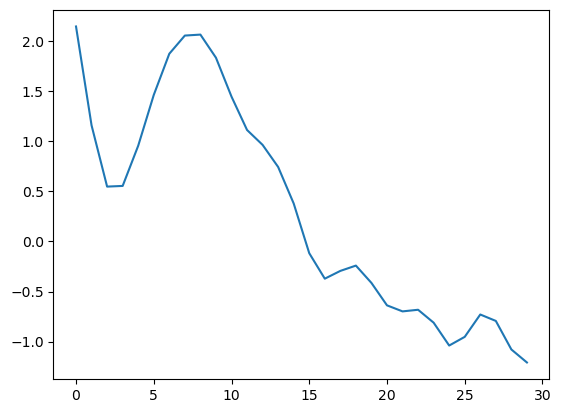

In [35]:
plt.plot(test_std[5])

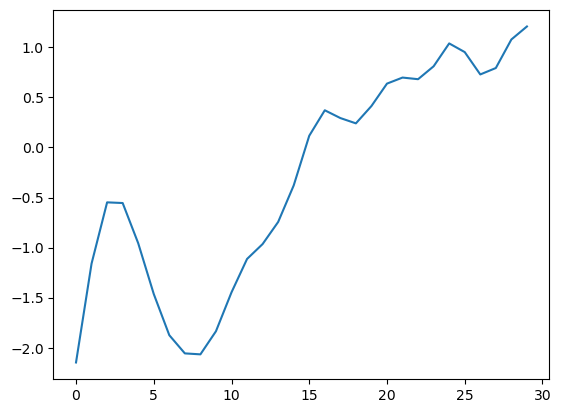

In [626]:
plt.plot(test_std[5])

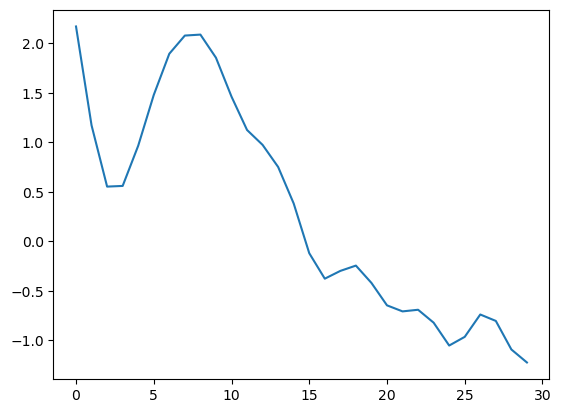

In [613]:
plt.plot(pc1_reshape[5]/std)